# Gradient Flow Population Validation

Validate numerically that $\mu(t) \to 0$ under approximate population gradient flow for 1D 2-class Gaussian data, a 2-ReLU hidden-layer NN, and an LDA head with trainable class means $\pm \mu$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sample_population(N, m, seed=0):
    rng = np.random.default_rng(seed)
    y = rng.choice([-1.0, 1.0], size=N)  # equal priors
    x = y * m + rng.standard_normal(size=N)  # variance 1
    return x, y


def relu(u):
    return np.maximum(u, 0.0)


def forward(x, params):
    # params: v1,v2,w1,w2,b1,b2,c
    v1, v2, w1, w2, b1, b2, c = params
    s1 = w1 * x + b1
    s2 = w2 * x + b2
    h1 = relu(s1)
    h2 = relu(s2)
    f = v1 * h1 + v2 * h2 + c
    cache = (s1, s2, h1, h2)
    return f, cache


def gradients(x, y, mu, params):
    """
    Population-gradient estimator for gradient ascent on:
        L = const - 0.5 * E[(f - y*mu)^2]
    Using r = y*mu - f.

    Returns:
        dmu (scalar), dparams (shape (7,))
    """
    v1, v2, w1, w2, b1, b2, c = params
    f, (s1, s2, h1, h2) = forward(x, params)
    r = y * mu - f

    # dL/dmu = E[y f] - mu  (equivalently E[y*(f - y*mu)])
    dmu = np.mean(y * f) - mu

    # For parameters: dL/dp = E[ r * df/dp ]
    ind1 = (s1 > 0.0).astype(float)
    ind2 = (s2 > 0.0).astype(float)

    df_dv1 = h1
    df_dv2 = h2
    df_dw1 = v1 * ind1 * x
    df_dw2 = v2 * ind2 * x
    df_db1 = v1 * ind1
    df_db2 = v2 * ind2
    df_dc = np.ones_like(x)

    dparams = np.array([
        np.mean(r * df_dv1),
        np.mean(r * df_dv2),
        np.mean(r * df_dw1),
        np.mean(r * df_dw2),
        np.mean(r * df_db1),
        np.mean(r * df_db2),
        np.mean(r * df_dc),
    ])

    return dmu, dparams


In [2]:
def run(m=1.0, N=200_000, steps=20_000, lr_mu=0.02, lr_theta=0.02, seed=1):
    # Big fixed Monte Carlo sample ~ population expectation
    x, y = sample_population(N=N, m=m, seed=seed)

    rng = np.random.default_rng(seed + 123)

    # Initialize parameters small-ish
    params = rng.normal(scale=0.2, size=7).astype(float)
    # Optionally start with c=0 to avoid early bias drift (not required)
    params[-1] = 0.0

    mu = 1.0  # start nonzero

    mu_hist = np.empty(steps, dtype=float)
    L_hist = np.empty(steps, dtype=float)

    for t in range(steps):
        # Compute gradients (population approx)
        dmu, dparams = gradients(x, y, mu, params)

        # Euler step for gradient ascent on L
        mu = mu + lr_mu * dmu
        params = params + lr_theta * dparams

        # Track
        f, _ = forward(x, params)
        # log-likelihood up to constant:
        L = -0.5 * np.mean((f - y * mu) ** 2)

        mu_hist[t] = mu
        L_hist[t] = L

        # light logging
        if (t + 1) % (steps // 10) == 0:
            print(f"step {t+1:6d}/{steps} | mu={mu:+.6f} | L={L:+.6f}")

    return mu, params, mu_hist, L_hist



Running with m=0.5
step    200/2000 | mu=+0.029016 | L=-0.000423
step    400/2000 | mu=+0.010521 | L=-0.000189
step    600/2000 | mu=+0.008416 | L=-0.000129
step    800/2000 | mu=+0.006966 | L=-0.000089
step   1000/2000 | mu=+0.005817 | L=-0.000063
step   1200/2000 | mu=+0.004897 | L=-0.000045
step   1400/2000 | mu=+0.004149 | L=-0.000033
step   1600/2000 | mu=+0.003535 | L=-0.000025
step   1800/2000 | mu=+0.003026 | L=-0.000019
step   2000/2000 | mu=+0.002600 | L=-0.000015
Final mu (m=0.5): +0.00260006

Running with m=1.0
step    200/2000 | mu=+0.061086 | L=-0.001068
step    400/2000 | mu=+0.039000 | L=-0.000641
step    600/2000 | mu=+0.032052 | L=-0.000444
step    800/2000 | mu=+0.026778 | L=-0.000315
step   1000/2000 | mu=+0.022516 | L=-0.000226
step   1200/2000 | mu=+0.018992 | L=-0.000163
step   1400/2000 | mu=+0.016045 | L=-0.000118
step   1600/2000 | mu=+0.013584 | L=-0.000086
step   1800/2000 | mu=+0.011542 | L=-0.000063
step   2000/2000 | mu=+0.009851 | L=-0.000046
Final mu (

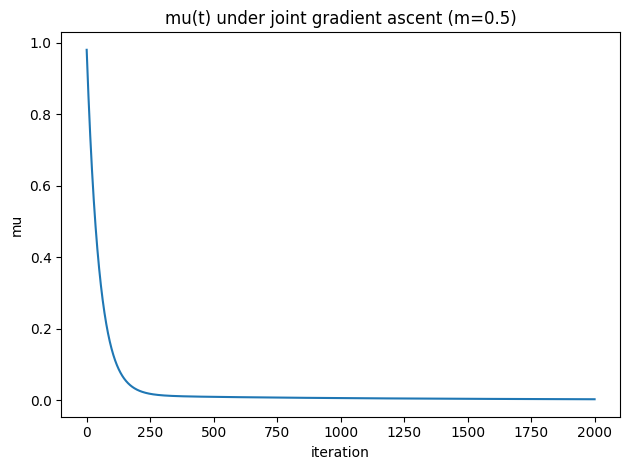

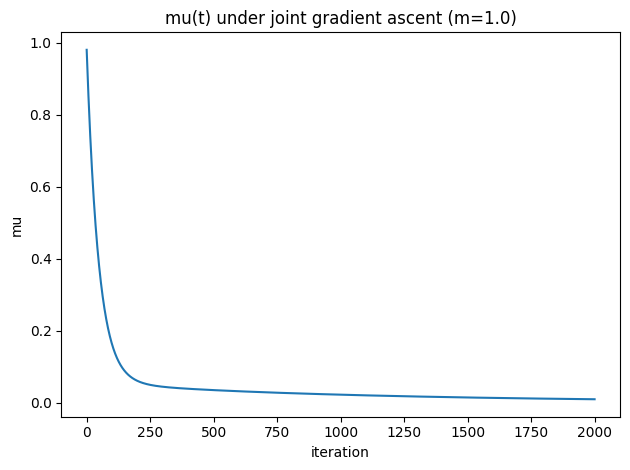

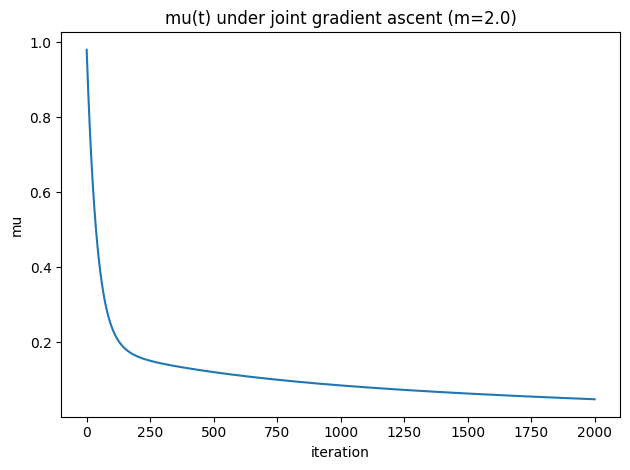

In [3]:
# Try several separations m (finite m => overlap => collapse predicted)
for m in [0.5, 1.0, 2.0]:
    print("\n" + "=" * 60)
    print(f"Running with m={m}")
    mu_final, params_final, mu_hist, L_hist = run(
        m=m,
        N=200_000,
        steps=2_000,
        lr_mu=0.02,
        lr_theta=0.02,
        seed=7,
    )
    print(f"Final mu (m={m}): {mu_final:+.8f}")

    # Plot mu(t)
    plt.figure()
    plt.plot(mu_hist)
    plt.xlabel("iteration")
    plt.ylabel("mu")
    plt.title(f"mu(t) under joint gradient ascent (m={m})")
    plt.tight_layout()

plt.show()
